In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # For visualizing our results

In [ ]:
# Load the dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# We drop NaN values to prevent math errors during parameter estimation.
x = df['no2'].dropna().values

print(f"Successfully loaded {len(x)} valid NO2 data points.")

C:\Users\HP\AppData\Local\Temp\ipykernel_21600\4111902455.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='ISO-8859-1')


Successfully loaded 419509 valid NO2 data points.


In [4]:
# Parameters for Roll Number 102303658
a_r = 0.1
b_r = 1.2

# Transform each value of x into z [cite: 6]
z = x + a_r * np.sin(b_r * x)

print("Data successfully transformed to z.")

Data successfully transformed to z.


In [5]:
# Calculate statistical mean and standard deviation
mu_estimated = np.mean(z)
sigma_estimated = np.std(z)
variance_estimated = sigma_estimated ** 2

# Map to the parameters required by the assignment equation [cite: 14]
mu = mu_estimated
lam = 1 / (2 * variance_estimated)
c = 1 / (sigma_estimated * np.sqrt(2 * np.pi))

print("--- Final Parameters to Submit ---")
print(f"μ (mu): {mu}")
print(f"λ (lambda): {lam}")
print(f"c: {c}")

--- Final Parameters to Submit ---
μ (mu): 25.807433312344642
λ (lambda): 0.001460149319761285
c: 0.02155875608156821


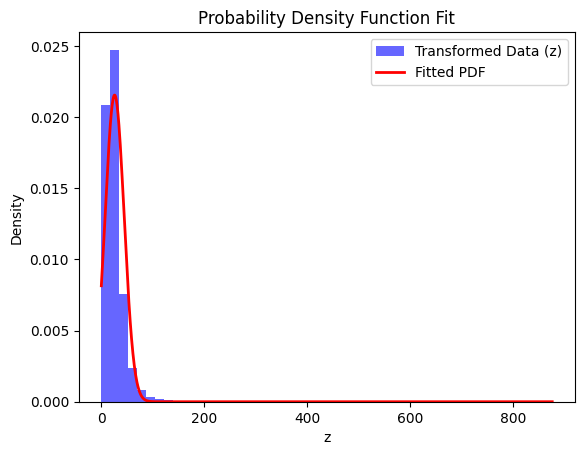

Graph successfully saved as 'pdf_fit_graph.png' in your current folder.


In [7]:
# Create a histogram of the transformed data
plt.hist(z, bins=50, density=True, alpha=0.6, color='b', label='Transformed Data (z)')

# Create the mathematical curve using our learned parameters
z_range = np.linspace(min(z), max(z), 1000)
p_z = c * np.exp(-lam * (z_range - mu)**2)

# Plot the curve
plt.plot(z_range, p_z, 'r', linewidth=2, label='Fitted PDF')
plt.title('Probability Density Function Fit')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()

# SAVE THE GRAPH BEFORE SHOWING IT
# You can change 'my_graph.png' to any name you prefer.
# dpi=300 makes it high resolution. bbox_inches='tight' prevents labels from getting cut off.
plt.savefig('pdf_fit_graph.png', dpi=300, bbox_inches='tight')

# Display the graph in the notebook
plt.show()

print("Graph successfully saved as 'pdf_fit_graph.png' in your current folder.")